# BioReason-Pro narrative scores — summary statistics

This notebook recomputes, **from the committed per-gene review files**, the
narrative-evaluation numbers quoted in `projects/BIOREASON_COMPARISON.md` and the
manuscript:

- overall mean **Correctness** and **Completeness** (RL: 3.7 / 2.9; SFT: 2.9 / 2.7)
- **Table 1** — score distribution
- **Table 2** — per-organism means
- top performers (5/5 correctness) and critical failures (1/5)
- a regenerated `per_organism_scores.png` figure

Each score is parsed directly from the `- **Correctness**: N/5` /
`- **Completeness**: N/5` lines in
`genes/<species>/<gene>/<gene>-bioreason-{rl,sft}-review.md`. Nothing is
hard-coded; re-running after adding/editing reviews updates every table.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
import bioreason_stats as bs

ROOT = bs.find_repo_root()
print("repo root:", ROOT)

rl = bs.parse_narrative_reviews("rl", ROOT)
sft = bs.parse_narrative_reviews("sft", ROOT)
print(f"RL  reviews parsed: {len(rl)}  (skipped: {len(rl.attrs['skipped'])})")
print(f"SFT reviews parsed: {len(sft)} (skipped: {len(sft.attrs['skipped'])})")
if sft.attrs["skipped"]:
    print("  skipped SFT files (no parseable score line):")
    for p in sft.attrs["skipped"]:
        print("   ", p)
rl.head()

repo root: /home/user/ai-gene-review
RL  reviews parsed: 139  (skipped: 0)
SFT reviews parsed: 43 (skipped: 1)
  skipped SFT files (no parseable score line):
    genes/human/SPDL1/SPDL1-bioreason-sft-review.md


,species,gene,correctness,completeness,path
0,9CAUD,dfrP,4,3,genes/9CAUD/dfrP/dfrP-bioreason-rl-review.md
1,AGKCO,fibrolase,2,2,genes/AGKCO/fibrolase/fibrolase-bioreason-rl-r...
2,ANOGA,PGRPLB,3,3,genes/ANOGA/PGRPLB/PGRPLB-bioreason-rl-review.md
3,ARATH,BRI1,5,4,genes/ARATH/BRI1/BRI1-bioreason-rl-review.md
4,ARATH,COP1,4,3,genes/ARATH/COP1/COP1-bioreason-rl-review.md


## Overall means

Compare the computed means against the values quoted in the manuscript.

In [2]:
def summarise(df, label):
    return dict(
        set=label,
        n=len(df),
        correctness=round(df.correctness.mean(), 2),
        completeness=round(df.completeness.mean(), 2),
    )

overall = pd.DataFrame([summarise(rl, "RL"), summarise(sft, "SFT")])
print(overall.to_string(index=False))
print("\nManuscript values -> RL: correctness 3.7, completeness 2.9 | "
      "SFT: correctness 2.9, completeness 2.7")

set   n  correctness  completeness
 RL 139         3.70          2.91
SFT  43         2.91          2.67

Manuscript values -> RL: correctness 3.7, completeness 2.9 | SFT: correctness 2.9, completeness 2.7


## Table 1 — score distribution (RL, 139 genes)

In [3]:
def distribution(df):
    out = pd.DataFrame(index=[5, 4, 3, 2, 1])
    for axis in ("correctness", "completeness"):
        counts = df[axis].value_counts().reindex([5, 4, 3, 2, 1], fill_value=0)
        pct = (100 * counts / len(df)).round(0).astype(int)
        out[axis] = [f"{c} ({p}%)" for c, p in zip(counts, pct)]
    out.index.name = "score"
    return out

dist = distribution(rl)
print(dist.to_string())

      correctness completeness
score                         
5        38 (27%)       1 (1%)
4        48 (35%)     40 (29%)
3        32 (23%)     51 (37%)
2        15 (11%)     40 (29%)
1          6 (4%)       7 (5%)


## Table 2 — per-organism means

Sorted by mean correctness, descending. `n` is the number of reviewed genes per clade.

In [4]:
per_org = (
    rl.groupby("species")
      .agg(n=("gene", "size"),
           correctness=("correctness", "mean"),
           completeness=("completeness", "mean"))
      .round(1)
      .sort_values("correctness", ascending=False)
)
print(per_org.to_string())

          n  correctness  completeness
species                               
mouse    11          4.7           3.6
rat      12          4.4           3.6
human    19          4.2           3.4
9CAUD     1          4.0           3.0
ARATH     3          4.0           3.3
yeast    11          3.9           2.6
BACSU    13          3.8           2.9
DROME     8          3.8           2.8
worm     15          3.5           2.3
PSEPK     8          3.4           3.0
ECOLI    13          3.2           3.0
ANOGA     1          3.0           3.0
SCHPO    23          2.8           2.3
AGKCO     1          2.0           2.0


### Figure: per-organism correctness & completeness

Regenerated from the parsed scores and written next to this notebook. It should match the committed `article/figures/per_organism_scores.png`.

saved figures/per_organism_scores.repro.png


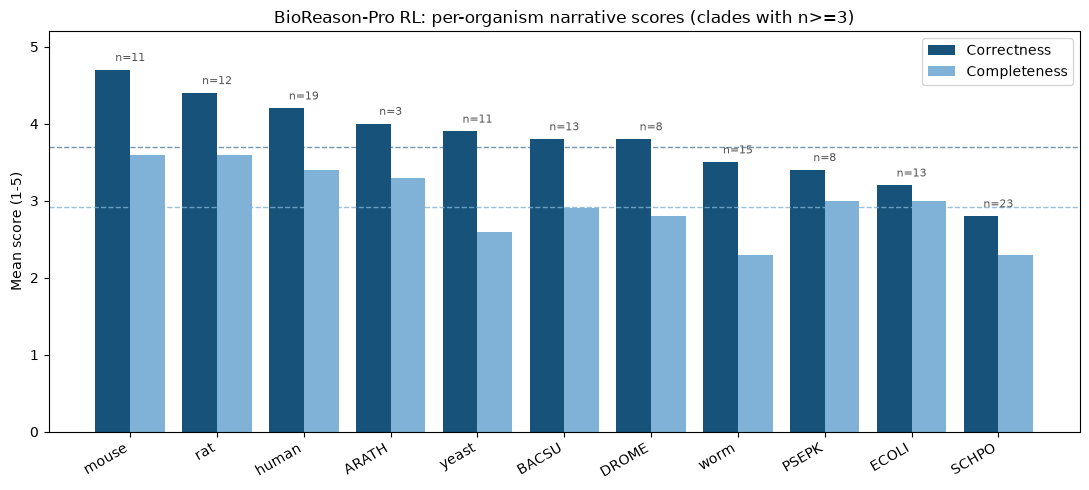

In [5]:
fig_df = per_org[per_org.n >= 3]  # mirror the manuscript figure (multi-gene clades)
x = range(len(fig_df))
w = 0.4
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([i - w/2 for i in x], fig_df.correctness, width=w, label="Correctness", color="#16527a")
ax.bar([i + w/2 for i in x], fig_df.completeness, width=w, label="Completeness", color="#7fb2d6")
ax.axhline(rl.correctness.mean(), ls="--", lw=1, color="#16527a", alpha=.6)
ax.axhline(rl.completeness.mean(), ls="--", lw=1, color="#7fb2d6", alpha=.8)
for i, (sp, row) in zip(x, fig_df.iterrows()):
    ax.text(i, max(row.correctness, row.completeness) + 0.08, f"n={int(row.n)}",
            ha="center", va="bottom", fontsize=8, color="#555")
ax.set_xticks(list(x))
ax.set_xticklabels(fig_df.index, rotation=30, ha="right")
ax.set_ylim(0, 5.2)
ax.set_ylabel("Mean score (1-5)")
ax.set_title("BioReason-Pro RL: per-organism narrative scores (clades with n>=3)")
ax.legend(loc="upper right")
fig.tight_layout()
outdir = Path("figures")
outdir.mkdir(exist_ok=True)
fig.savefig(outdir / "per_organism_scores.repro.png", dpi=120)
print("saved", outdir / "per_organism_scores.repro.png")
plt.show()

## Top performers and critical failures

In [6]:
top = rl[rl.correctness == 5].sort_values("completeness", ascending=False)
fails = rl[rl.correctness == 1]
print(f"Correctness 5/5: {len(top)} genes")
print(top[["species", "gene", "completeness"]].to_string(index=False))
print(f"\nCorrectness 1/5 (critical failures): {len(fails)} genes")
print(fails[["species", "gene", "completeness"]].to_string(index=False))

both5 = rl[(rl.correctness == 5) & (rl.completeness == 5)]
print(f"\nGenes scoring 5/5 on BOTH axes: {len(both5)} -> "
      f"{list(both5.gene)}  (manuscript: only Uggt1)")

Correctness 5/5: 38 genes
species   gene  completeness
    rat  Uggt1             5
  ARATH   BRI1             4
  BACSU   ftsZ             4
  BACSU  spo0A             4
  ECOLI  GroEL             4
  BACSU   amyE             4
   worm  lgg-1             4
  SCHPO   ura7             4
  human   EGFR             4
  human   BCL2             4
  human   PTEN             4
  human NOTCH1             4
  human   TP53             4
  human    MYC             4
  mouse   Pten             4
  mouse  Calm1             4
  mouse   Egfr             4
  mouse    Myc             4
    rat   Akt1             4
    rat   Egfr             4
  mouse  Trp53             4
  mouse   Akt1             4
    rat   Tp53             4
  yeast   TOR1             4
   worm  cmd-1             4
    rat  Hspa5             4
    rat  Mapk1             4
  SCHPO   bst1             3
  human  VEGFA             3
  SCHPO   tpx1             3
  mouse    Src             3
  mouse    Fyn             3
    rat  Hspa8   

## SFT vs RL cross-check

The SFT narrative set scores lower than RL, consistent with the paper's claim that SFT has more hallucinations.

In [7]:
sft_dist = distribution(sft)
print("SFT score distribution:")
print(sft_dist.to_string())
print()
print(pd.DataFrame([summarise(rl, "RL"), summarise(sft, "SFT")]).to_string(index=False))

SFT score distribution:
      correctness completeness
score                         
5          0 (0%)       0 (0%)
4        14 (33%)      5 (12%)
3        17 (40%)     23 (53%)
2         7 (16%)     12 (28%)
1          4 (9%)       2 (5%)

set   n  correctness  completeness
 RL 139         3.70          2.91
SFT  43         2.91          2.67
